In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models


In [6]:
!unzip Dataset.zip

Archive:  Dataset.zip
  inflating: brain_tumor_dataset/no/1 no.jpeg  
  inflating: brain_tumor_dataset/no/10 no.jpg  
  inflating: brain_tumor_dataset/no/11 no.jpg  
  inflating: brain_tumor_dataset/no/12 no.jpg  
  inflating: brain_tumor_dataset/no/13 no.jpg  
  inflating: brain_tumor_dataset/no/14 no.jpg  
  inflating: brain_tumor_dataset/no/15 no.jpg  
  inflating: brain_tumor_dataset/no/17 no.jpg  
  inflating: brain_tumor_dataset/no/18 no.jpg  
  inflating: brain_tumor_dataset/no/19 no.jpg  
  inflating: brain_tumor_dataset/no/2 no.jpeg  
  inflating: brain_tumor_dataset/no/20 no.jpg  
  inflating: brain_tumor_dataset/no/21 no.jpg  
  inflating: brain_tumor_dataset/no/22 no.jpg  
  inflating: brain_tumor_dataset/no/23 no.jpg  
  inflating: brain_tumor_dataset/no/24 no.jpg  
  inflating: brain_tumor_dataset/no/25 no.jpg  
  inflating: brain_tumor_dataset/no/26 no.jpg  
  inflating: brain_tumor_dataset/no/27 no.jpg  
  inflating: brain_tumor_dataset/no/28 no.jpg  
  inflating: brain

In [18]:
# ── 1. Setup ──────────────────────────────────────────
img_size   = 224
batch_size = 32


train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    "/content",
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    classes=['yes', 'no']   # ← explicitly tell it only these 2 folders
)

val_generator = train_datagen.flow_from_directory(
    "/content",
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    classes=['yes', 'no']   # ← same here
)


Found 203 images belonging to 2 classes.
Found 50 images belonging to 2 classes.


In [19]:
# ── 2. Build CNN ──────────────────────────────────────
model = models.Sequential()
model.add(layers.Input(shape=(224, 224, 3)))
model.add(layers.Conv2D(32, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(2, 2))
model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(2, 2))
model.add(layers.Conv2D(128, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(2, 2))
model.add(layers.Flatten())
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dense(2, activation='softmax'))  # ← 2 = yes/no

In [20]:
# ── 3. Compile ────────────────────────────────────────
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ── 4. Train ──────────────────────────────────────────
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator
)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.5567 - loss: 1.4362 - val_accuracy: 0.7600 - val_loss: 0.5839
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - accuracy: 0.7833 - loss: 0.5383 - val_accuracy: 0.7400 - val_loss: 0.5431
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 110ms/step - accuracy: 0.8227 - loss: 0.4640 - val_accuracy: 0.7600 - val_loss: 0.5404
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - accuracy: 0.8325 - loss: 0.4162 - val_accuracy: 0.7600 - val_loss: 0.5444
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - accuracy: 0.8571 - loss: 0.3356 - val_accuracy: 0.7200 - val_loss: 0.4568
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - accuracy: 0.9015 - loss: 0.2393 - val_accuracy: 0.8000 - val_loss: 0.4206
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 104ms/step - accuracy: 0.9212 - loss: 0.1831 - val_accuracy: 0.8400 - val_loss: 0.4872
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - accuracy: 0.9557 - loss: 0.1033 - val_accuracy: 0.8200 - val_loss: 0.5589

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.8600 - loss: 0.4686
Validation Accuracy: 0.8600000143051147


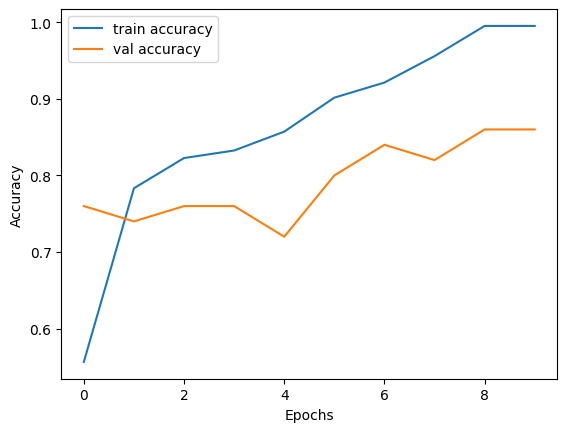

In [21]:
# ── 5. Evaluate ───────────────────────────────────────
loss, accuracy = model.evaluate(val_generator)
print("Validation Accuracy:", accuracy)

# ── 6. Plot ───────────────────────────────────────────
plt.plot(history.history['accuracy'],     label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()